# Boundary and Initial Conditions

This notebook is the next step after the first vanilla PINN baseline.

The question is no longer whether a PINN can fit one simple forward PDE at all. The question is how we should enforce the constraints that make a PDE problem well posed. In practice, that choice often changes optimization behavior as much as the network architecture does.


## Notebook Contract

- **Status:** core-executable
- **Research question:** On a simple time-dependent PDE, how do soft and hard enforcement strategies change boundary-condition satisfaction, initial-condition satisfaction, and overall solution quality?
- **Canonical problem:** 1D heat equation with homogeneous Dirichlet boundary conditions and a sinusoidal initial condition
- **Main comparison:** soft-constraint PINN vs hard-constrained PINN under the same model size and training budget


## Why This Notebook Exists

Notebook `02` used a boundary value problem where the only constraint question was how strongly to penalize the two boundary endpoints.

This notebook moves to the smallest time-dependent PDE that introduces both boundary conditions and an initial condition. That lets us study two standard strategies:

- **soft enforcement:** keep the network output unconstrained and add BC or IC penalties to the loss,
- **hard enforcement:** build the constraints directly into the model output so they are satisfied by construction.

Neither strategy is universally better. The point of this notebook is to make the trade-off concrete on one clean benchmark.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE

We study the 1D heat equation on the space-time domain $(x, t) \in [0, 1] \times [0, 1]$:

$$
u_t(x, t) - u_{xx}(x, t) = 0,
$$

with homogeneous Dirichlet boundary conditions

$$
u(0, t) = 0, \qquad u(1, t) = 0,
$$

and initial condition

$$
u(x, 0) = \sin(\pi x).
$$

This problem has the exact solution

$$
u^*(x, t) = e^{-\pi^2 t} \sin(\pi x).
$$

It is a good teaching problem because:

- the PDE residual is still simple,
- the boundary and initial constraints are both easy to state,
- the exact solution is available for evaluation,
- a hard-constrained ansatz can be written down analytically.


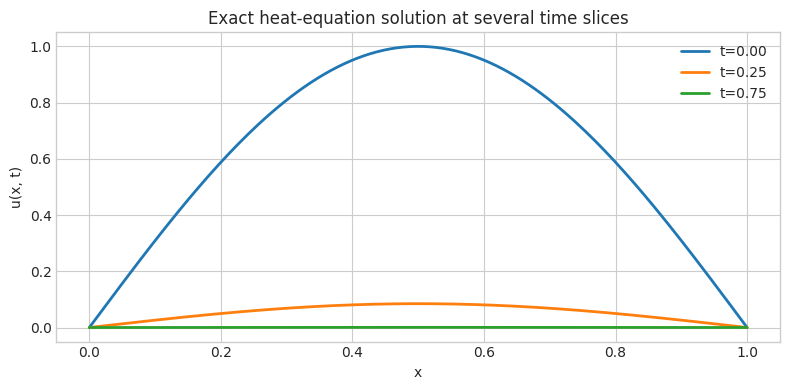

In [2]:
def exact_solution_np(x: np.ndarray, t: np.ndarray) -> np.ndarray:
    return np.exp(-(np.pi ** 2) * t) * np.sin(np.pi * x)


def exact_solution_torch(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    return torch.exp(-(torch.pi ** 2) * t) * torch.sin(torch.pi * x)


x_plot = np.linspace(0.0, 1.0, 200)
t_slices = [0.0, 0.25, 0.75]

plt.figure(figsize=(8, 4))
for t_value in t_slices:
    plt.plot(x_plot, exact_solution_np(x_plot, t_value * np.ones_like(x_plot)), linewidth=2, label=f"t={t_value:.2f}")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Exact heat-equation solution at several time slices")
plt.legend()
plt.tight_layout()
plt.show()


## Two Enforcement Strategies

For the **soft** model, we let the network output $u_\theta(x, t)$ directly and minimize

$$
\mathcal{L}_{soft} = \mathcal{L}_{physics} + \lambda_{bc}\mathcal{L}_{bc} + \lambda_{ic}\mathcal{L}_{ic}.
$$

For the **hard** model, we start from an unconstrained neural output $n_\theta(x, t)$ and wrap it in an ansatz

$$
u_\theta^{hard}(x, t) = x(1-x)t\, n_\theta(x, t) + (1-t)\sin(\pi x).
$$

This ansatz is designed so that:

- at $t=0$, the first term vanishes and the initial condition is recovered exactly,
- at $x=0$ or $x=1$, the prefactor $x(1-x)$ vanishes and the boundary conditions are recovered exactly.

The hard model therefore only needs a physics loss, but the optimization landscape changes because the network is now wrapped in a structured transformation.


In [3]:
def gradient(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def heat_residual(u: torch.Tensor, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    u_t = gradient(u, t)
    u_x = gradient(u, x)
    u_xx = gradient(u_x, x)
    return u_t - u_xx


def make_interior_points(nx: int, nt: int):
    x = torch.linspace(0.0, 1.0, nx + 2, device=device)[1:-1]
    t = torch.linspace(0.0, 1.0, nt + 2, device=device)[1:-1]
    xx, tt = torch.meshgrid(x, t, indexing="ij")
    x_interior = xx.reshape(-1, 1).clone().detach().requires_grad_(True)
    t_interior = tt.reshape(-1, 1).clone().detach().requires_grad_(True)
    return x_interior, t_interior


def make_boundary_points(nt: int):
    t = torch.linspace(0.0, 1.0, nt + 2, device=device)[1:-1].view(-1, 1)
    x_left = torch.zeros_like(t)
    x_right = torch.ones_like(t)
    return x_left, x_right, t


def make_initial_points(nx: int):
    x = torch.linspace(0.0, 1.0, nx + 2, device=device)[1:-1].view(-1, 1)
    t = torch.zeros_like(x)
    return x, t


In [4]:
class SpaceTimeMLP(nn.Module):
    def __init__(self, in_dim: int = 2, width: int = 32, depth: int = 2):
        super().__init__()
        layers: list[nn.Module] = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.net(inputs)


class SoftPINN(nn.Module):
    def __init__(self, width: int = 32, depth: int = 2):
        super().__init__()
        self.net = SpaceTimeMLP(width=width, depth=depth)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x, t], dim=1))


class HardPINN(nn.Module):
    def __init__(self, width: int = 32, depth: int = 2):
        super().__init__()
        self.net = SpaceTimeMLP(width=width, depth=depth)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        raw = self.net(torch.cat([x, t], dim=1))
        return x * (1.0 - x) * t * raw + (1.0 - t) * torch.sin(torch.pi * x)


def build_training_data(config: dict[str, float | int]):
    x_interior, t_interior = make_interior_points(config["nx_interior"], config["nt_interior"])
    x_left, x_right, t_boundary = make_boundary_points(config["nt_boundary"])
    x_initial, t_initial = make_initial_points(config["nx_initial"])
    return {
        "x_interior": x_interior,
        "t_interior": t_interior,
        "x_left": x_left,
        "x_right": x_right,
        "t_boundary": t_boundary,
        "x_initial": x_initial,
        "t_initial": t_initial,
    }


def compute_losses(
    model: nn.Module,
    mode: str,
    batch: dict[str, torch.Tensor],
    bc_weight: float,
    ic_weight: float,
) -> dict[str, torch.Tensor]:
    u_interior = model(batch["x_interior"], batch["t_interior"])
    residual = heat_residual(u_interior, batch["x_interior"], batch["t_interior"])
    physics_loss = torch.mean(residual.square())

    if mode == "soft":
        left_boundary = model(batch["x_left"], batch["t_boundary"])
        right_boundary = model(batch["x_right"], batch["t_boundary"])
        initial_values = model(batch["x_initial"], batch["t_initial"])
        bc_loss = 0.5 * (torch.mean(left_boundary.square()) + torch.mean(right_boundary.square()))
        ic_loss = torch.mean((initial_values - torch.sin(torch.pi * batch["x_initial"])).square())
        total_loss = physics_loss + bc_weight * bc_loss + ic_weight * ic_loss
    elif mode == "hard":
        bc_loss = torch.zeros(1, device=device, dtype=physics_loss.dtype).squeeze()
        ic_loss = torch.zeros(1, device=device, dtype=physics_loss.dtype).squeeze()
        total_loss = physics_loss
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return {
        "total": total_loss,
        "physics": physics_loss,
        "bc": bc_loss,
        "ic": ic_loss,
    }


## Training Setup

We keep the comparison narrow and fair:

- both models use the same MLP width and depth,
- both are trained with Adam at the same learning rate,
- both see the same interior collocation grid,
- only the enforcement mechanism changes.

The soft model spends part of its optimization budget learning the constraints. The hard model satisfies them automatically, but pays for that convenience through a more structured output map.


In [5]:
config = {
    "width": 32,
    "depth": 2,
    "learning_rate": 1e-3,
    "steps": 2000,
    "nx_interior": 20,
    "nt_interior": 20,
    "nt_boundary": 40,
    "nx_initial": 80,
    "bc_weight": 20.0,
    "ic_weight": 20.0,
}

batch = build_training_data(config)


def train_model(mode: str, config: dict[str, float | int], batch: dict[str, torch.Tensor]):
    if mode == "soft":
        model: nn.Module = SoftPINN(width=config["width"], depth=config["depth"]).to(device)
    elif mode == "hard":
        model = HardPINN(width=config["width"], depth=config["depth"]).to(device)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    history = {"step": [], "total": [], "physics": [], "bc": [], "ic": []}

    for step in range(1, config["steps"] + 1):
        optimizer.zero_grad()
        losses = compute_losses(
            model=model,
            mode=mode,
            batch=batch,
            bc_weight=config["bc_weight"],
            ic_weight=config["ic_weight"],
        )
        losses["total"].backward()
        optimizer.step()

        if step == 1 or step % 400 == 0:
            history["step"].append(step)
            for key in ["total", "physics", "bc", "ic"]:
                history[key].append(losses[key].detach().item())
            print(
                f"[{mode}] step={step:4d} | total={history['total'][-1]:.3e} | "
                f"physics={history['physics'][-1]:.3e} | bc={history['bc'][-1]:.3e} | ic={history['ic'][-1]:.3e}"
            )

    return model, history


soft_model, soft_history = train_model(mode="soft", config=config, batch=batch)
hard_model, hard_history = train_model(mode="hard", config=config, batch=batch)


[soft] step=   1 | total=8.938e+00 | physics=3.978e-03 | bc=9.806e-04 | ic=4.457e-01


[soft] step= 400 | total=1.504e+00 | physics=1.819e-01 | bc=2.278e-02 | ic=4.330e-02


[soft] step= 800 | total=1.528e-01 | physics=7.224e-02 | bc=1.165e-03 | ic=2.864e-03


[soft] step=1200 | total=2.926e-02 | physics=2.130e-02 | bc=1.102e-04 | ic=2.878e-04


[soft] step=1600 | total=8.282e-03 | physics=6.020e-03 | bc=3.040e-05 | ic=8.266e-05


...

[hard] step= 400 | total=1.840e+00 | physics=1.840e+00 | bc=0.000e+00 | ic=0.000e+00


[hard] step= 800 | total=4.222e-01 | physics=4.222e-01 | bc=0.000e+00 | ic=0.000e+00


[hard] step=1200 | total=1.733e-01 | physics=1.733e-01 | bc=0.000e+00 | ic=0.000e+00


[hard] step=1600 | total=8.186e-02 | physics=8.186e-02 | bc=0.000e+00 | ic=0.000e+00


[hard] step=2000 | total=4.143e-02 | physics=4.143e-02 | bc=0.000e+00 | ic=0.000e+00


## Evaluation Metrics

We evaluate both models on the same dense space-time grid and track five quantities:

- max error against the exact solution,
- L2 error against the exact solution,
- mean absolute PDE residual,
- mean absolute boundary violation,
- mean absolute initial-condition violation.

The hard model should drive the last two almost exactly to zero by construction. The more interesting question is what happens to the solution error and the residual under the same optimization budget.


In [6]:
def evaluate_model(model: nn.Module, label: str):
    x_eval = torch.linspace(0.0, 1.0, 61, device=device)
    t_eval = torch.linspace(0.0, 1.0, 61, device=device)
    xx, tt = torch.meshgrid(x_eval, t_eval, indexing="ij")

    x_flat = xx.reshape(-1, 1).clone().detach().requires_grad_(True)
    t_flat = tt.reshape(-1, 1).clone().detach().requires_grad_(True)

    u_pred = model(x_flat, t_flat)
    u_exact = exact_solution_torch(x_flat, t_flat)
    residual = heat_residual(u_pred, x_flat, t_flat)

    boundary_t = torch.linspace(0.0, 1.0, 61, device=device).view(-1, 1)
    boundary_left = model(torch.zeros_like(boundary_t), boundary_t)
    boundary_right = model(torch.ones_like(boundary_t), boundary_t)

    initial_x = torch.linspace(0.0, 1.0, 61, device=device).view(-1, 1)
    initial_pred = model(initial_x, torch.zeros_like(initial_x))
    initial_exact = torch.sin(torch.pi * initial_x)

    metrics = {
        "label": label,
        "max_error": torch.max(torch.abs(u_pred - u_exact)).detach().item(),
        "l2_error": torch.sqrt(torch.mean((u_pred - u_exact).square())).detach().item(),
        "mean_abs_residual": torch.mean(torch.abs(residual)).detach().item(),
        "mean_abs_bc_violation": 0.5
        * (
            torch.mean(torch.abs(boundary_left)).detach().item()
            + torch.mean(torch.abs(boundary_right)).detach().item()
        ),
        "mean_abs_ic_violation": torch.mean(torch.abs(initial_pred - initial_exact)).detach().item(),
    }

    fields = {
        "x_grid": xx.detach().cpu().numpy(),
        "t_grid": tt.detach().cpu().numpy(),
        "u_pred": u_pred.detach().cpu().numpy().reshape(xx.shape),
        "u_exact": u_exact.detach().cpu().numpy().reshape(xx.shape),
        "residual": residual.detach().cpu().numpy().reshape(xx.shape),
    }
    return metrics, fields


soft_metrics, soft_fields = evaluate_model(soft_model, label="soft")
hard_metrics, hard_fields = evaluate_model(hard_model, label="hard")

for metrics in [soft_metrics, hard_metrics]:
    print(metrics["label"].upper())
    print(f"  max error:              {metrics['max_error']:.3e}")
    print(f"  L2 error:               {metrics['l2_error']:.3e}")
    print(f"  mean abs residual:      {metrics['mean_abs_residual']:.3e}")
    print(f"  mean abs BC violation:  {metrics['mean_abs_bc_violation']:.3e}")
    print(f"  mean abs IC violation:  {metrics['mean_abs_ic_violation']:.3e}")


SOFT
  max error:              2.919e-02
  L2 error:               5.445e-03
  mean abs residual:      8.146e-02
  mean abs BC violation:  3.894e-03
  mean abs IC violation:  5.535e-03
HARD
  max error:              8.721e-02
  L2 error:               1.722e-02
  mean abs residual:      1.435e-01
  mean abs BC violation:  2.186e-08
  mean abs IC violation:  0.000e+00


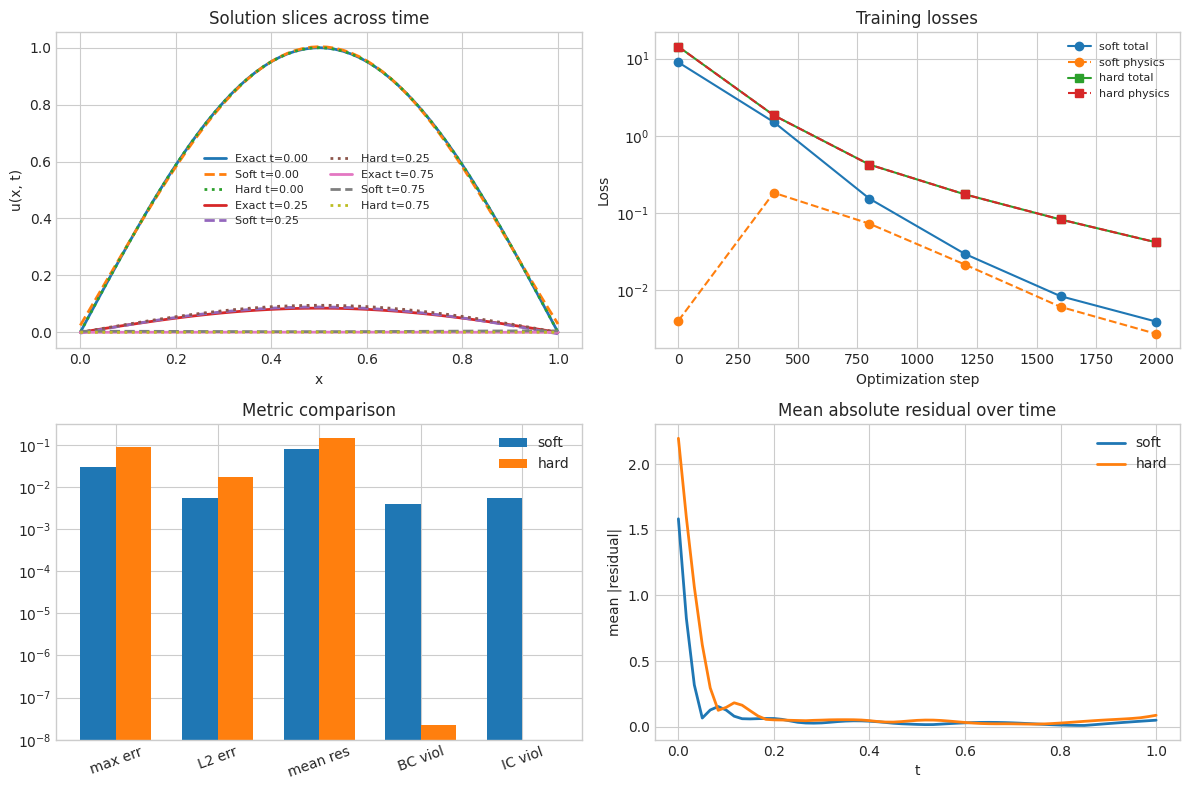

In [7]:
snapshot_times = [0.0, 0.25, 0.75]
x_axis = soft_fields["x_grid"][:, 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for t_value in snapshot_times:
    time_index = np.argmin(np.abs(soft_fields["t_grid"][0] - t_value))
    exact_slice = soft_fields["u_exact"][:, time_index]
    soft_slice = soft_fields["u_pred"][:, time_index]
    hard_slice = hard_fields["u_pred"][:, time_index]
    axes[0, 0].plot(x_axis, exact_slice, linewidth=2, label=f"Exact t={t_value:.2f}")
    axes[0, 0].plot(x_axis, soft_slice, linestyle="--", linewidth=2, label=f"Soft t={t_value:.2f}")
    axes[0, 0].plot(x_axis, hard_slice, linestyle=":", linewidth=2, label=f"Hard t={t_value:.2f}")

axes[0, 0].set_title("Solution slices across time")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("u(x, t)")
axes[0, 0].legend(fontsize=8, ncol=2)

axes[0, 1].plot(soft_history["step"], soft_history["total"], "o-", label="soft total")
axes[0, 1].plot(soft_history["step"], soft_history["physics"], "o--", label="soft physics")
axes[0, 1].plot(hard_history["step"], hard_history["total"], "s-", label="hard total")
axes[0, 1].plot(hard_history["step"], hard_history["physics"], "s--", label="hard physics")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Training losses")
axes[0, 1].set_xlabel("Optimization step")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(fontsize=8)

metric_names = [
    "max_error",
    "l2_error",
    "mean_abs_residual",
    "mean_abs_bc_violation",
    "mean_abs_ic_violation",
]
soft_values = [soft_metrics[name] for name in metric_names]
hard_values = [hard_metrics[name] for name in metric_names]
positions = np.arange(len(metric_names))
width = 0.35

axes[1, 0].bar(positions - width / 2, soft_values, width=width, label="soft")
axes[1, 0].bar(positions + width / 2, hard_values, width=width, label="hard")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xticks(positions)
axes[1, 0].set_xticklabels(["max err", "L2 err", "mean res", "BC viol", "IC viol"], rotation=20)
axes[1, 0].set_title("Metric comparison")
axes[1, 0].legend()

axes[1, 1].plot(soft_fields["t_grid"][0], np.mean(np.abs(soft_fields["residual"]), axis=0), label="soft", linewidth=2)
axes[1, 1].plot(hard_fields["t_grid"][0], np.mean(np.abs(hard_fields["residual"]), axis=0), label="hard", linewidth=2)
axes[1, 1].set_title("Mean absolute residual over time")
axes[1, 1].set_xlabel("t")
axes[1, 1].set_ylabel("mean |residual|")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Interpretation

This benchmark shows why BC or IC handling deserves its own notebook.

- The **soft** model can spend its capacity directly fitting the solution and often reaches lower solution error under a fixed training budget.
- The **hard** model enforces the constraints essentially exactly, which is valuable when constraint satisfaction is non-negotiable.
- Exact enforcement is not free. The output ansatz changes the optimization problem, and with the same optimizer and budget the hard model can still end up with a larger residual or larger solution error.

That trade-off is the core lesson. Choosing between soft and hard enforcement is an optimization and modeling decision, not just a matter of mathematical elegance.


## Key Takeaways

- Time-dependent PDEs force us to think about both boundary conditions and initial conditions explicitly.
- Soft enforcement gives the optimizer freedom, but constraint satisfaction is only approximate.
- Hard enforcement gives exact BC or IC satisfaction by construction, but can change the training landscape in non-trivial ways.
- The next notebook will stay with PINNs but shift focus again: once the constraints are defined, how does the loss geometry affect training dynamics?


## Next Step

Notebook `04` will build on this comparison and study why PINN optimization can still become unstable even when the PDE and the constraints are written down correctly.
